# Analiza supraviețuirii pe Titanic

## 1. Rata globală de supraviețuire

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

##importul setului de date titanic
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
df['Survived'].value_counts(normalize=True) * 100

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

#### Observăm că din toți pasagerii ponderea celor supraviețuiți este 62% față de 38% decedati din totalul 891 de pasageri

## 2. Grupam pasagerii per sex pentru identificarea procentului de supravețuiți

In [3]:
df.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

#### Observăm că dintre totalul de femei au supraviețuit in proportie de 74% iar din totalul de bărbati au supraviețuit doar 19%

## 3. Gruparea per clasa biletului 1/2/3

In [4]:
df.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

#### Observăm că per clase separat avem următoarele proporții:
#### Clasa 1 au supraviețuit în proporție de 63%
#### Clasa 2 au supraviețuit în proporție de 47%
#### Clasa 3 au supraviețuit în proporție de 24%

## 4. Gruparea per sex și clasa bieltului pentru identifiacrea păstrării propirțiilor in fiecare clasă ca citeriu sex

In [5]:
df.groupby(['Sex', 'Pclass'])['Survived'].mean()

Sex     Pclass
female  1         0.968085
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: Survived, dtype: float64

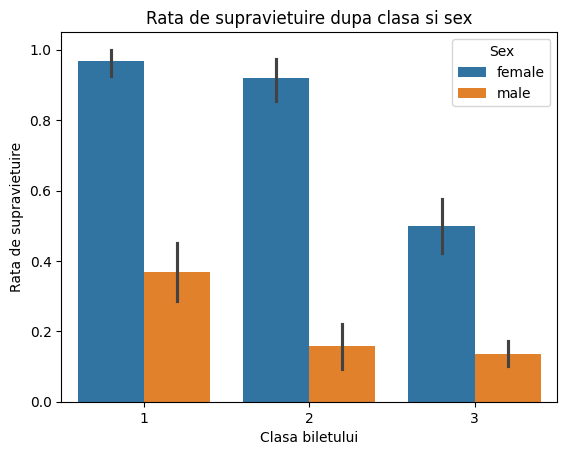

In [6]:
sns.barplot(data=df, x='Pclass', y='Survived', hue='Sex')
plt.title('Rata de supravietuire dupa clasa si sex')
plt.ylabel('Rata de supravietuire')
plt.xlabel('Clasa biletului')
plt.show()

#### Sexul a fost factorul decisiv de supraviețuire — femeile au supraviețuit în proporție mult mai mare decât bărbații în toate cele 3 clase. Clasa biletului a contat și ea, dar mai ales pentru femei — cele din clasa 1 aveau șanse de aproape 2 ori mai mari față de cele din clasa 3, probabil din cauza poziției cabinelor pe navă. Bărbații din clasele 2 și 3 au avut cele mai mici șanse — sub 20%

## 5. Identificarea punctului de inflexiune pentru vârstă ca criteriu de supraviețuire

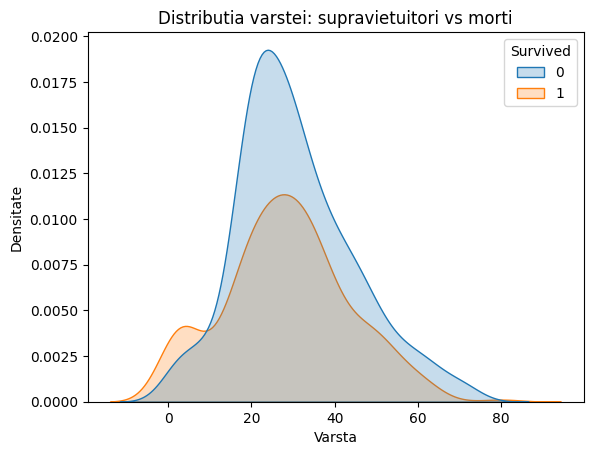

In [7]:
sns.kdeplot(data=df, x='Age', hue='Survived', fill=True)
plt.title('Distributia varstei: supravietuitori vs morti')
plt.xlabel('Varsta')
plt.ylabel('Densitate')
plt.show()

#### Din graficul dat identificăm că singurul interval in care cei supraviețuiți depășesc cei morți este pentru vârsta de până la 10 ani. Dovadă al respectării  protocolului ”children first”

## 6. Curățarea datelor

Am identificat 177 valori lipsă pentru vârstă, distribuite 
neuniform — 136 din clasa 3. Pentru a păstra restul datelor 
valoroase ale acestor pasageri, înlocuim valorile lipsă cu 
mediana vârstei. Analizele anterioare pe Sex și Pclass 
nu sunt afectate.

In [11]:
df['Age'].isnull().sum()

np.int64(177)

In [12]:
df[df['Age'].isnull()]['Pclass'].value_counts()

Pclass
3    136
1     30
2     11
Name: count, dtype: int64

In [13]:
mediana_varsta = df['Age'].median()
df['Age'] = df['Age'].fillna(mediana_varsta)
print(f"Mediana vârstei: {mediana_varsta}")
print(df['Age'].isnull().sum())

Mediana vârstei: 28.0
0


In [15]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## 7. Concluzii

- Sexul a fost cel mai puternic factor de supraviețuire: 
  74% femei vs 19% bărbați
- Clasa biletului a contat semnificativ: 
  63% clasa 1 vs 24% clasa 3
- Combinația sex + clasă arată că bărbații din clasele 2 și 3 
  au avut cele mai mici șanse — sub 20%
- Copiii sub 10 ani au avut șanse mai mari de supraviețuire 
  față de adulți
- 687 valori lipsă pentru Cabin fac această coloană inutilizabilă